# Exercise no. 3: Filtering
Consider the raw ECG (lead I) signal of a healthy participant provided in the csv file *ecgiddb_person02_rec1.csv*. This signal is extracted from the public available PhysioNet ECG-ID dataset (https://physionet.org/content/ecgiddb/1.0.0/).

The raw ECG signal is recorded for 20 seconds, sampled at 500 Hz with 12-bit resolution over a nominal ±10 mV range. As the provided signal is a raw signal, it is contaminated by both high and low frequency noise components. Example of these components, affecting the provided ECG, are the powerline noise -- occurring at 50 Hz and multiples -- and the baseline wandering noise -- occurring at low frequencies (0.1-0.5 Hz) -- mainly due to breathing or subject movement.

Implement a Python script that:
- Loads the signal. Plots the signal in time and plots the amplitude spectrum of the raw signal (fft with N points, where N is the number of samples in the signal).
- Progressively filters out the noise components, plots the filtered signal in time and plots the amplitude spectrum of the filtered signal (as in point i.). To this aim, design and apply the following IIR elliptic filters:
    - High-pass filter (rp=0.1, rs=80, gpass=0.1, gstop=80, Wp=0.5, Ws=0.1).
    - Low-pass filter (rp=0.1, rs=80, gpass=0.1, gstop=80, Wp=40, Ws=42), similar to M. Ingale et al. (2020) [1] on the same dataset. Alternatively, you can use a bank of band-stop filters centered at multiples of 50 Hz. As an example: Wp1=W-4, Ws1=W-2, Ws2=W+2, Wp2=W+4, with W=[50, 100, 150, 200].

Consider also using zero-phase IIR filters. Compare the results with or without zero-phase filtering.



Hints. Use numpy methods (e.g., *loadtxt*), matplotlib.pyplot methods (e.g., *plot*), scipy.fft methods (*fft*), scipy.signal methods (https://docs.scipy.org/doc/scipy/reference/signal.html#filtering, https://docs.scipy.org/doc/scipy/reference/signal.html#matlab-style-iir-filter-design).

Note.  
A more appropriate way for designing the band-stop filters of point b. -- with a narrow bandwidth in the attenuation band -- is to use IIR notch filters. A notch filter is a band-stop filter that is specifically designed for rejecting a narrow frequency band (e.g., from 48 to 52 Hz), see *scipy.signal.iirnotch*. It is widely used for removing powerline noise.

## References
[1] M. Ingale, R. Cordeiro, S. Thentu, Y. Park and N. Karimian, "ECG Biometric Authentication: A Comparative Analysis" in IEEE Access, vol. 8, pp. 117853-117866, 2020, doi: 10.1109/ACCESS.2020.3004464.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy

(10000, 2)


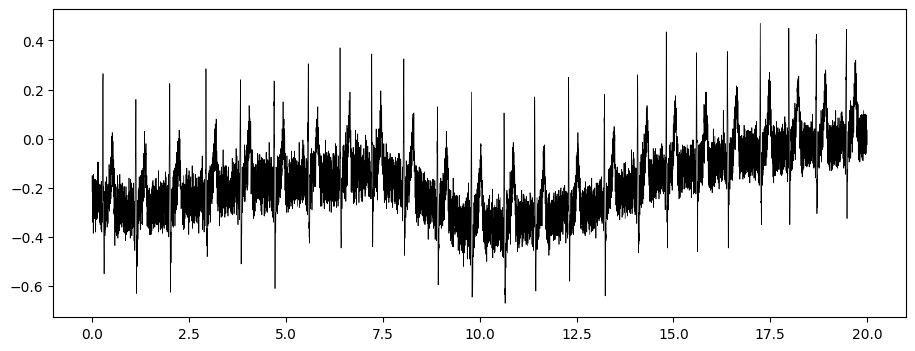

In [2]:
x = np.loadtxt('ecgiddb_person02_rec1.csv', delimiter=',')
print(x.shape)
time = x[:, 0]
ecg = x[:, 1]
plt.figure(figsize=(11,8/2))
plt.plot(time, ecg, 'k', linewidth=0.5)


In [3]:
def plot_amplitude_spectrum(x, fs, dB=False):
    N = x.shape[0]
    X = scipy.fft.fft(x) # DFT by default (M=N points)
    freq = np.arange(N)*fs/N
    plt.figure(figsize=(8,11/3))
    y = np.abs(X[0:int(N/2+1)]) if not dB else 20*np.log10(np.abs(X[0:int(N/2+1)]))
    plt.plot(freq[0:int(N/2+1)], y, 'k', linewidth=0.5)
    plt.xlabel('frequency (Hz)')
    plt.ylabel('Amplitude spectrum')

def plot_filter_amplitude_spectrum(b,a,fs, dB=False):
    w, h = scipy.signal.freqz(b, a, fs=fs)
    plt.figure(figsize=(8,11/3))
    y = np.abs(h) if not dB else 20 * np.log10(np.abs(h))
    plt.plot(w, y)
    plt.xlabel('frequency (Hz)')
    plt.ylabel('Filter amplitude spectrum')

nsamples: 10000, fs: 500.0


Text(0, 0.5, 'ECG I (mV)')

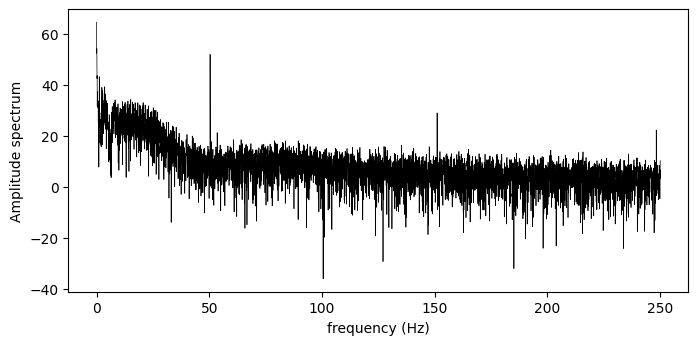

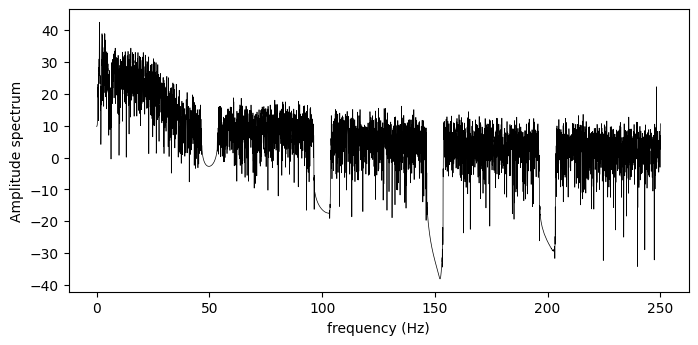

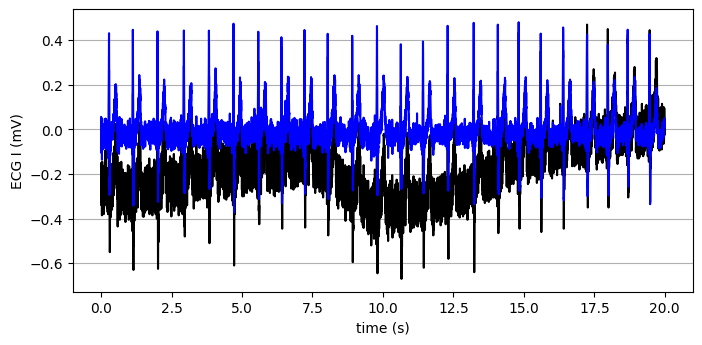

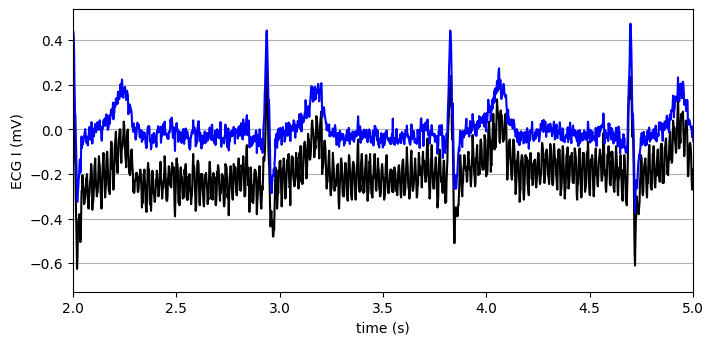

In [4]:
data = np.loadtxt('ecgiddb_person02_rec1.csv', delimiter=',')
time = data[:, 0]
fs = 1/(time[1]-time[0])
ecg = data[:, 1]

print('nsamples: {0}, fs: {1}'.format(time.shape[0], fs))

plot_amplitude_spectrum(ecg, fs, dB=True)

N = len(ecg)

Rp = 0.1
Rs = 80

# high-pass
Wp = 0.5
Ws = 0.1
n, Wn = scipy.signal.ellipord(Wp, Ws, Rp, Rs, fs=fs)
b, a = scipy.signal.ellip(n, Rp, Rs, Wn, btype='highpass', fs=fs)
ecg_f = scipy.signal.filtfilt(b, a, ecg)

# band-stop centering the attenuation band at multiples of 50 Hz
for f in [50, 100, 150, 200, ]:
    Wp = [f-4, f+4]
    Ws = [f-2, f+2]
    n, Wn = scipy.signal.ellipord(Wp, Ws, Rp, Rs,fs=fs)
    b, a = scipy.signal.ellip(n, Rp, Rs, Wn, btype='bandstop',fs=fs)
    ecg_f = scipy.signal.filtfilt(b, a, ecg_f)

plot_amplitude_spectrum(ecg_f, fs, dB=True)

plt.figure(figsize=(8,11/3))
plt.plot(time, ecg, 'k')
plt.plot(time, ecg_f, 'b')
plt.grid(axis='y')
plt.xlabel('time (s)')
plt.ylabel('ECG I (mV)')

plt.figure(figsize=(8,11/3))
plt.plot(time, ecg, 'k')
plt.plot(time, ecg_f, 'b')
plt.grid(axis='y')
plt.xlim([2, 5])
plt.xlabel('time (s)')
plt.ylabel('ECG I (mV)')



nsamples: 10000, fs: 500.0


Text(0, 0.5, 'ECG I (mV)')

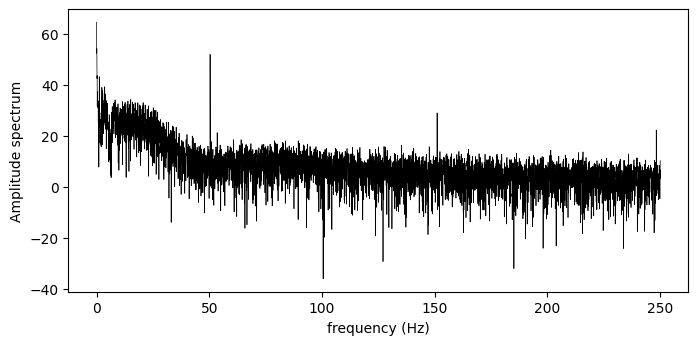

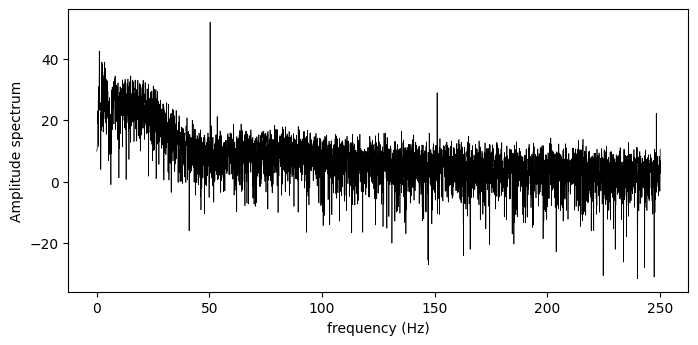

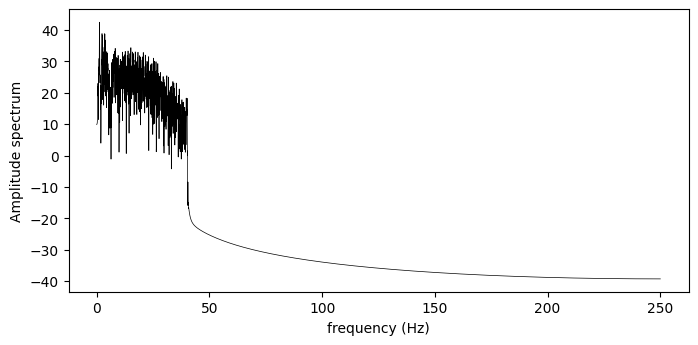

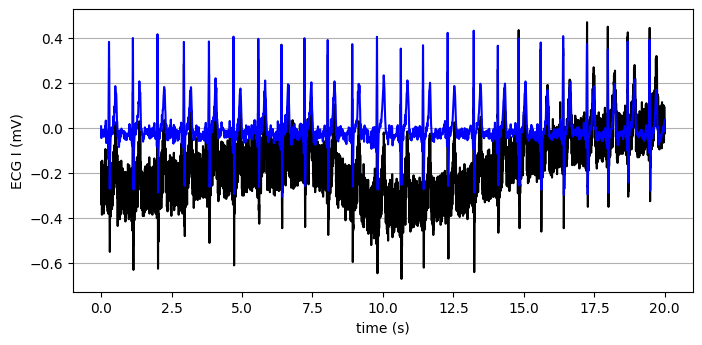

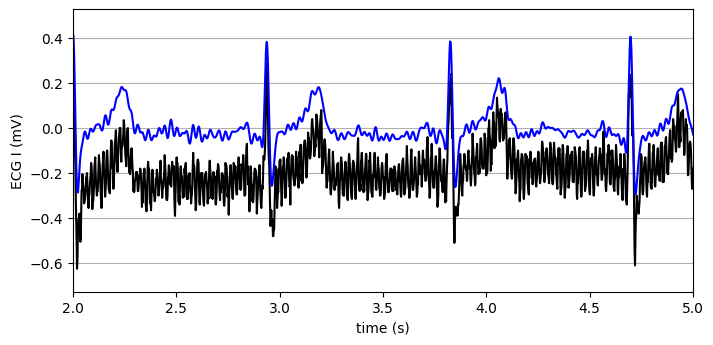

In [5]:
data = np.loadtxt('ecgiddb_person02_rec1.csv', delimiter=',')
time = data[:, 0]
fs = 1/(time[1]-time[0])
ecg = data[:, 1]

print('nsamples: {0}, fs: {1}'.format(time.shape[0], fs))

plot_amplitude_spectrum(ecg, fs, dB=True)

N = len(ecg)

Rp = 0.1
Rs = 80

# high-pass
Wp = 0.5
Ws = 0.1
n, Wn = scipy.signal.ellipord(Wp, Ws, Rp, Rs, fs=fs)
b, a = scipy.signal.ellip(n, Rp, Rs, Wn, btype='highpass', fs=fs)
ecg_f = scipy.signal.filtfilt(b, a, ecg)

plot_amplitude_spectrum(ecg_f, fs, dB=True)

Wp = 40
Ws = 42
n, Wn = scipy.signal.ellipord(Wp, Ws, Rp, Rs, fs=fs)
b, a = scipy.signal.ellip(n, Rp, Rs, Wn, 'lowpass', fs=fs)
ecg_f = scipy.signal.filtfilt(b, a, ecg_f)

plot_amplitude_spectrum(ecg_f, fs, dB=True)

plt.figure(figsize=(8,11/3))
plt.plot(time, ecg, 'k')
plt.plot(time, ecg_f, 'b')
plt.grid(axis='y')
plt.xlabel('time (s)')
plt.ylabel('ECG I (mV)')

plt.figure(figsize=(8,11/3))
plt.plot(time, ecg, 'k')
plt.plot(time, ecg_f, 'b')
plt.grid(axis='y')
plt.xlim([2, 5])
plt.xlabel('time (s)')
plt.ylabel('ECG I (mV)')